In [1]:
import pandas as pd

In [4]:
df=pd.read_csv('atis_intents.csv')
df.head(10)

,atis_flight,i want to fly from boston at 838 am and arrive in denver at 1110 in the morning
0,atis_flight,what flights are available from pittsburgh to...
1,atis_flight_time,what is the arrival time in san francisco for...
2,atis_airfare,cheapest airfare from tacoma to orlando
3,atis_airfare,round trip fares from pittsburgh to philadelp...
4,atis_flight,i need a flight tomorrow from columbus to min...
5,atis_aircraft,what kind of aircraft is used on a flight fro...
6,atis_flight,show me the flights from pittsburgh to los an...
7,atis_flight,all flights from boston to washington
8,atis_ground_service,what kind of ground transportation is availab...
9,atis_flight,show me the flights from dallas to san francisco


In [5]:
df.columns = ['intent','text']

In [6]:
df.head(10)

,intent,text
0,atis_flight,what flights are available from pittsburgh to...
1,atis_flight_time,what is the arrival time in san francisco for...
2,atis_airfare,cheapest airfare from tacoma to orlando
3,atis_airfare,round trip fares from pittsburgh to philadelp...
4,atis_flight,i need a flight tomorrow from columbus to min...
5,atis_aircraft,what kind of aircraft is used on a flight fro...
6,atis_flight,show me the flights from pittsburgh to los an...
7,atis_flight,all flights from boston to washington
8,atis_ground_service,what kind of ground transportation is availab...
9,atis_flight,show me the flights from dallas to san francisco


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4977 entries, 0 to 4976
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   intent  4977 non-null   object
 1   text    4977 non-null   object
dtypes: object(2)
memory usage: 77.9+ KB


In [8]:
df['intent'].value_counts()

intent
atis_flight                                 3665
atis_airfare                                 423
atis_ground_service                          255
atis_airline                                 157
atis_abbreviation                            147
atis_aircraft                                 81
atis_flight_time                              54
atis_quantity                                 51
atis_flight#atis_airfare                      21
atis_airport                                  20
atis_distance                                 20
atis_city                                     19
atis_ground_fare                              18
atis_capacity                                 16
atis_flight_no                                12
atis_meal                                      6
atis_restriction                               6
atis_airline#atis_flight_no                    2
atis_ground_service#atis_ground_fare           1
atis_airfare#atis_flight_time                  1
atis_cheapest

In [10]:
df.shape
df['intent'].nunique()

22

In [12]:
classes = df['intent'].value_counts()
print(classes)

intent
atis_flight                                 3665
atis_airfare                                 423
atis_ground_service                          255
atis_airline                                 157
atis_abbreviation                            147
atis_aircraft                                 81
atis_flight_time                              54
atis_quantity                                 51
atis_flight#atis_airfare                      21
atis_airport                                  20
atis_distance                                 20
atis_city                                     19
atis_ground_fare                              18
atis_capacity                                 16
atis_flight_no                                12
atis_meal                                      6
atis_restriction                               6
atis_airline#atis_flight_no                    2
atis_ground_service#atis_ground_fare           1
atis_airfare#atis_flight_time                  1
atis_cheapest

In [13]:
valid_classes=classes[classes>=30].index
print(valid_classes)

Index(['atis_flight', 'atis_airfare', 'atis_ground_service', 'atis_airline',
       'atis_abbreviation', 'atis_aircraft', 'atis_flight_time',
       'atis_quantity'],
      dtype='object', name='intent')


In [14]:
import numpy as np

In [15]:
df['intent_clean'] = df['intent'].where(
    df['intent'].isin(valid_classes), 'atis_other')

In [16]:
df.shape

(4977, 3)

In [17]:
df['intent_clean'].nunique()

9

In [18]:
df.head(10)

,intent,text,intent_clean
0,atis_flight,what flights are available from pittsburgh to...,atis_flight
1,atis_flight_time,what is the arrival time in san francisco for...,atis_flight_time
2,atis_airfare,cheapest airfare from tacoma to orlando,atis_airfare
3,atis_airfare,round trip fares from pittsburgh to philadelp...,atis_airfare
4,atis_flight,i need a flight tomorrow from columbus to min...,atis_flight
5,atis_aircraft,what kind of aircraft is used on a flight fro...,atis_aircraft
6,atis_flight,show me the flights from pittsburgh to los an...,atis_flight
7,atis_flight,all flights from boston to washington,atis_flight
8,atis_ground_service,what kind of ground transportation is availab...,atis_ground_service
9,atis_flight,show me the flights from dallas to san francisco,atis_flight


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

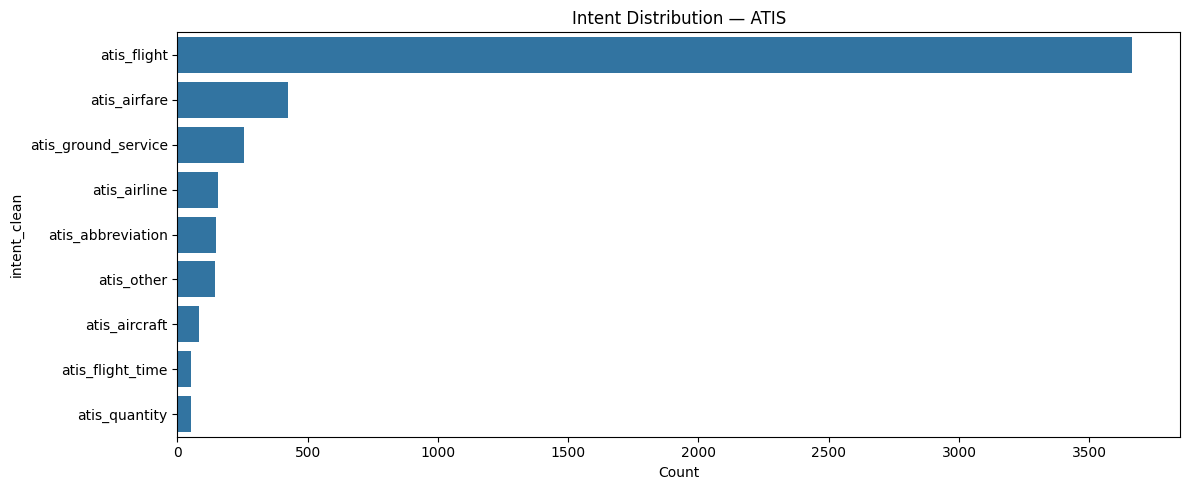

In [21]:
plt.figure(figsize=(12, 5))
sns.countplot(y='intent_clean', data=df, order=df['intent_clean'].value_counts().index)
plt.title('Intent Distribution — ATIS')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

In [22]:
df = df.drop('intent', axis=1)

In [23]:
df.head(10)

,text,intent_clean
0,what flights are available from pittsburgh to...,atis_flight
1,what is the arrival time in san francisco for...,atis_flight_time
2,cheapest airfare from tacoma to orlando,atis_airfare
3,round trip fares from pittsburgh to philadelp...,atis_airfare
4,i need a flight tomorrow from columbus to min...,atis_flight
5,what kind of aircraft is used on a flight fro...,atis_aircraft
6,show me the flights from pittsburgh to los an...,atis_flight
7,all flights from boston to washington,atis_flight
8,what kind of ground transportation is availab...,atis_ground_service
9,show me the flights from dallas to san francisco,atis_flight


In [24]:
print(df['intent_clean'].value_counts())

intent_clean
atis_flight            3665
atis_airfare            423
atis_ground_service     255
atis_airline            157
atis_abbreviation       147
atis_other              144
atis_aircraft            81
atis_flight_time         54
atis_quantity            51
Name: count, dtype: int64


In [26]:
print(df[df['intent_clean'] == 'atis_other'].shape[0])


144


In [27]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [28]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [29]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"'", '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words
             if w not in stop_words]
    return ' '.join(words)

In [30]:
df['cleaned_text'] = df['text'].apply(clean_text)

In [31]:
print("BEFORE:", df['text'].iloc[0])
print("AFTER:", df['cleaned_text'].iloc[0])

BEFORE:  what flights are available from pittsburgh to baltimore on thursday morning
AFTER: flight available pittsburgh baltimore thursday morning


In [32]:
le = LabelEncoder()
y = le.fit_transform(df['intent_clean'])
print("\nClasses:", le.classes_)


Classes: ['atis_abbreviation' 'atis_aircraft' 'atis_airfare' 'atis_airline'
 'atis_flight' 'atis_flight_time' 'atis_ground_service' 'atis_other'
 'atis_quantity']


In [36]:
X = df['cleaned_text']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [37]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000,
        min_df=2,
        max_df=0.95,
        ngram_range=(1, 2)  # ← new parameter
    )),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'  # ← handles imbalance
    ))
])

In [38]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [39]:
print(classification_report(y_test, y_pred,
                           target_names=le.classes_))

                     precision    recall  f1-score   support

  atis_abbreviation       0.92      0.83      0.87        29
      atis_aircraft       0.79      0.94      0.86        16
       atis_airfare       0.83      0.98      0.90        85
       atis_airline       0.62      0.97      0.76        31
        atis_flight       0.98      0.93      0.95       734
   atis_flight_time       0.55      1.00      0.71        11
atis_ground_service       0.98      0.90      0.94        51
         atis_other       0.57      0.55      0.56        29
      atis_quantity       0.75      0.90      0.82        10

           accuracy                           0.92       996
          macro avg       0.78      0.89      0.82       996
       weighted avg       0.93      0.92      0.92       996



In [40]:
cm = confusion_matrix(y_test, y_pred)

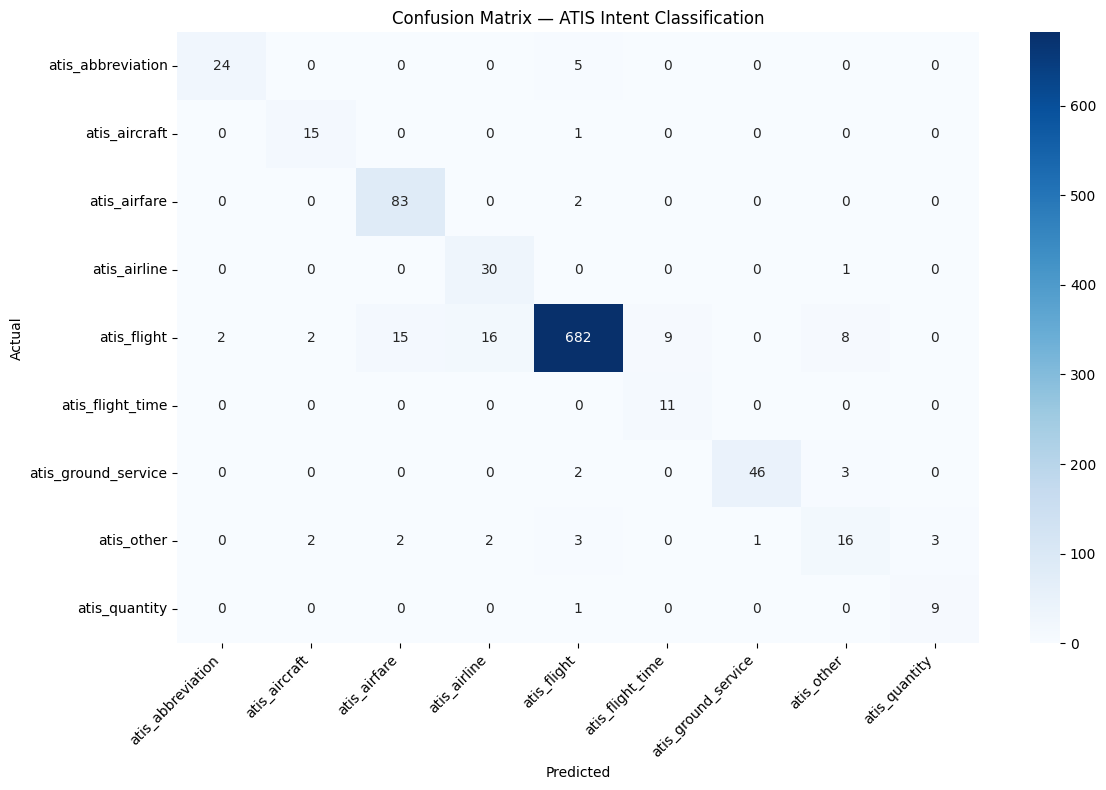

In [41]:
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.title('Confusion Matrix — ATIS Intent Classification')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [42]:
import joblib

joblib.dump(pipeline, 'atis_model.pkl')
joblib.dump(le, 'atis_label_encoder.pkl')
print("Model saved.")
print(f"Classes: {le.classes_}")

Model saved.
Classes: ['atis_abbreviation' 'atis_aircraft' 'atis_airfare' 'atis_airline'
 'atis_flight' 'atis_flight_time' 'atis_ground_service' 'atis_other'
 'atis_quantity']
